In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

In [80]:
df = pd.read_csv("../data/cleaned_listings.csv")

In [81]:
df["log_price"]

0       4.574711
1       3.806662
2       4.510860
3       4.143135
4       5.402677
          ...   
2532    4.787492
2533    5.283204
2534    4.804021
2535    4.605170
2536    4.110874
Name: log_price, Length: 2537, dtype: float64

In [82]:
df.head()

,price,room_type,accommodates,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable,amenities,has_reviews,amenities_count,log_price
0,96.0,Entire home/apt,2,1.0,1.0,1.0,35.578640,-82.595780,28806,4.62,4.46,4.92,4.58,1,1,"[""Coffee maker"", ""Wifi"", ""Fire extinguisher"", ...",1,29,4.574711
1,44.0,Private room,2,1.0,1.0,1.0,35.577350,-82.638040,28806,4.92,4.98,4.86,4.97,1,0,"[""Electric stove"", ""Clothing storage: closet"",...",1,47,3.806662
2,90.0,Entire home/apt,4,1.0,2.0,1.0,35.617641,-82.551819,28804,4.89,4.85,4.94,4.80,0,0,"[""Coffee maker"", ""Clothing storage: walk-in cl...",1,42,4.510860
3,62.0,Private room,2,1.0,1.0,1.0,35.596150,-82.506350,28805,4.66,4.57,4.67,4.59,0,0,"[""Coffee maker"", ""Wifi"", ""Dishwasher"", ""Fire e...",1,26,4.143135
4,221.0,Entire home/apt,6,4.0,5.0,2.0,35.585610,-82.627310,28806,4.94,4.91,4.91,4.91,1,1,"[""Garden view"", ""Outdoor dining area"", ""Clothi...",1,64,5.402677


In [83]:
df.isnull().sum()

price                        0
room_type                    0
accommodates                 0
bedrooms                     0
beds                         0
bathrooms                    0
latitude                     0
longitude                    0
neighbourhood_cleansed       0
review_scores_rating         0
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
host_is_superhost            0
instant_bookable             0
amenities                    0
has_reviews                  0
amenities_count              0
log_price                    0
dtype: int64

In [84]:
#all the features that could influence price (that are signficant) are listed here
#excluded the type of amenities, only included the number of amenities, otherwise the model would be incredibly hard to train, especially with limited computing power
features = [
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "latitude",
    "longitude",
    "neighbourhood_cleansed",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "host_is_superhost",
    "instant_bookable",
    "amenities_count",
    "has_reviews"
]


In [85]:
x = df[features]
y = df["log_price"]

We're splitting features and log_price (we're using log price for it to be easier to deal with massive discrepancies in size of numbers) to eventually try to determine how features affect log price 


In [86]:
#splitting categorical and numerical features
categorical = ["room_type", "neighbourhood_cleansed"]
numeric = [col for col in features if col not in categorical] #all features except for categorical ones

In [87]:
#here we do preprocessing, effectively we assign a 1 to the value in the category the row (AirBnb) corresponds to and 0s for all other values in that category. This allows us to deal with things numerically
#numerical categories are left alone)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)

In [88]:
#this is a pipeline, so the first thing it does it preprocess data
#the next thing it does is the regressor, which is a random forest regressor, meaning that it gets n_estimators trees to make predictions and finds the average of them
#we use a fixed random_state for consistent results, however, a more realistic approach would be to use a non-fixed random_state
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
     ]
)

In [89]:
#splits data into two parts: one to train and one to test, the test would take up 20% of data, and 80% would be training. 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [90]:
#training our model based on X_train and y_train values
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [91]:
#trying to predict the y_test values based on X_test and our model
predictions = model.predict(X_test)

In [92]:
#finding mean absolute error and correlation coefficient
#Not too performance for first time training model; almost 60% of deviations can be explained by our model
mae_log = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE (logarithmic):", mae_log)
print("R^2:", r2)

MAE (logarithmic): 0.2756249016841523
R^2: 0.5877324637625523


In [94]:
#undoing logarithmic scaling that I was doing earlier to find the standard price deviation
pred_price = np.expm1(predictions)
actual_price = np.expm1(y_test)
mae_dollars = mean_absolute_error(actual_price, pred_price)

print("Mean Absolute Error (in dollars):", mae_dollars)


Mean Absolute Error (in dollars): 48.92752296246812


In [59]:
df["price"].describe()

count    2537.000000
mean      196.383918
std       405.674986
min        18.000000
25%        95.000000
50%       133.000000
75%       211.000000
max      9999.000000
Name: price, dtype: float64

Outlier removal was tested, but did not significantly improve performance due to the use of a logarithmic transformation, which already lessens the impact of extreme values. Right now, we have an R^2 value of around 0.6, and a Mean Absolute Error of around 50 dollars, which is totally acceptance when you acknowledge that most AirBnbs cost around 150 dollars, meaning that the predicted values would still be inbetween 100-200 dollars, and would usually be fairly close to the actual cost.

In [96]:
#now we're trying to find which values are the most important for determining the cost of an AirBnb
result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending = False)

print(importance_df)

                      feature  importance
4                   bathrooms    0.195611
1                accommodates    0.170134
7      neighbourhood_cleansed    0.105594
6                   longitude    0.091841
2                    bedrooms    0.085851
5                    latitude    0.048731
0                   room_type    0.040071
14            amenities_count    0.030610
8        review_scores_rating    0.026144
11        review_scores_value    0.018382
10     review_scores_location    0.010256
13           instant_bookable    0.009678
3                        beds    0.005576
12          host_is_superhost    0.005041
9   review_scores_cleanliness    0.004495
15                has_reviews   -0.001268


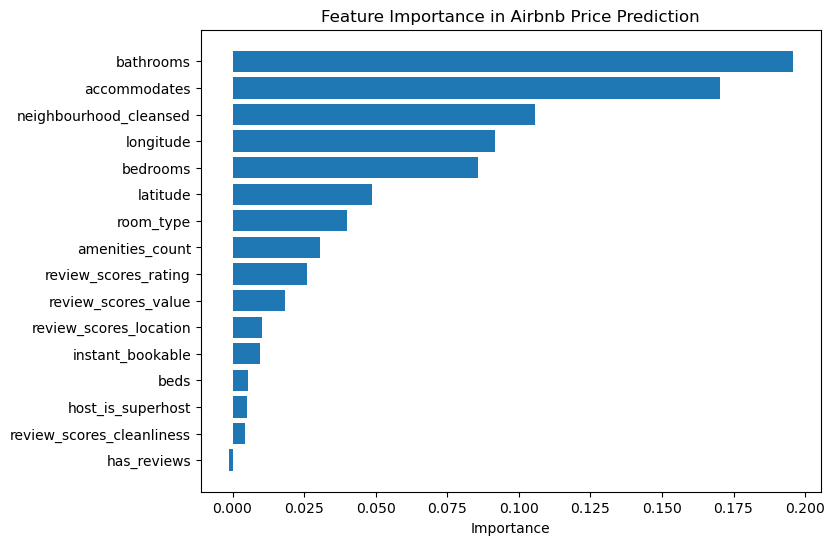

In [97]:
#visualizing this with a bar graph
plt.figure(figsize=(8,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance in Airbnb Price Prediction")
plt.show()